# KOZMOS ile Aspect-Based Duygu Analizi

Bu notebook, Türkçe ürün yorumlarında aspect-based duygu sınıflandırması yapar.  
Girdi formatı olarak yorum ve aspect bilgisi birlikte modele verilir:

`yorum [SEP] aspect -> pozitif / negatif / nötr`

Deneyde yorum bazlı group split kullanılmıştır. Böylece aynı yorumun farklı aspect satırları train ve test kümelerine dağılmayarak veri sızıntısı riski azaltılmıştır.

In [ ]:
# KOZMOS (YTÜ) ile Aspect-Based Duygu Analizi
# Branch: yontem_cozmos  |  Sorumlu: Ahmet Çağlar
# Colab ortamında eksik paketler için kurulum hücresi.
!pip install transformers datasets scikit-learn seaborn wordcloud -q

In [ ]:
# Deneyin aynı koşullarda tekrar üretilebilmesi için sabit seed kullanılır.
# set_seed; random, numpy ve torch tarafını birlikte sabitler.
from transformers import set_seed
SEED = 42
set_seed(SEED)

In [ ]:
# Train/validation/test dosyaları daha önce yorum bazlı group split ile oluşturulmuştur.
DATA_PATH = "/content/"
import pandas as pd
import numpy as np
# utf-8-sig, Türkçe karakterlerin CSV'den doğru okunması için kullanılır.
train_df = pd.read_csv(DATA_PATH + "train.csv", encoding="utf-8-sig")
test_df  = pd.read_csv(DATA_PATH + "test.csv",  encoding="utf-8-sig")
val_df   = pd.read_csv(DATA_PATH + "val.csv",   encoding="utf-8-sig")

print(f"Train: {train_df.shape}, Test: {test_df.shape}, Val: {val_df.shape}")
print(train_df["sentiment"].value_counts())

Train: (2342, 3), Test: (510, 3), Val: (506, 3)
sentiment
pozitif    1336
negatif     822
notr        184
Name: count, dtype: int64


In [ ]:
# Etiketler modele sayısal sınıf olarak verilir.
# ABSA için yorum ve hedef aspect aynı girdide birleştirilir.
# [SEP] token'ı yorum ile aspect bilgisini ayırır.
LABEL_MAP = {"negatif":0 , "notr": 1, "pozitif":2}
INV_LABEL = {v:i for i, v in LABEL_MAP.items()}
for df in [train_df, val_df, test_df]:
    df["label"] = df["sentiment"].map(LABEL_MAP)
    df["input_text"] = df["yorum"].astype(str) + " [SEP] " + df["aspect"].astype(str)

print("Örnek input:")
print(train_df["input_text"].iloc[0])
print("Label:", train_df["label"].iloc[0])

Örnek input:
ASUS ASUS ASUSU [SEP] genel
Label: 1


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch

# Nötr sınıfı veri içinde az temsil edildiği için sınıf ağırlıkları kullanılır.
classes = np.array([0, 1, 2])  # negatif=0, notr=1, pozitif=2
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values,
)
class_weights = torch.tensor(weights, dtype=torch.float)

print("Class weights:")
print(f"  negatif (0): {weights[0]:.3f}")
print(f"  notr    (1): {weights[1]:.3f}")
print(f"  pozitif (2): {weights[2]:.3f}")

Class weights:
  negatif (0): 0.950
  notr    (1): 4.243
  pozitif (2): 0.584


In [ ]:
# model yüklemesi ve tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "ytu-ce-cosmos/turkish-small-bert-uncased"
# Önceden eğitilmiş BERT gövdesi kullanılır. sınıflandırma katmanı 3 duygu sınıfı için yeniden başlatılır.
# Bu nedenle classifier ağırlıklarının eksik/yeni görünmesi beklenen bir durumdur.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Model:", MODEL_NAME)
print("Cihaz:", device)

model.safetensors:   0%|          | 0.00/119M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ytu-ce-cosmos/turkish-small-bert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: ytu-ce-cosmos/turkish-small-bert-uncased
Cihaz: cuda


In [ ]:
#Veri seti sınıfı
from torch.utils.data import Dataset
# her satır tokenlaştırılarak input_ids, attention_mask ve label formatına çevrilir.
# Maksimum uzunluk 128 token seçilmiştir.
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df["input_text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ABSADataset(train_df, tokenizer)
val_dataset   = ABSADataset(val_df,   tokenizer)
test_dataset  = ABSADataset(test_df,  tokenizer)

In [14]:
#Fine-tuning
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score
from torch.nn import CrossEntropyLoss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "macro_f1":    f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

# Az temsil edilen notr sınıfı için ağırlıklı kayıp
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        loss    = CrossEntropyLoss(weight=class_weights.to(logits.device))(logits, labels)
        return (loss, outputs) if return_outputs else loss

SAVE_PATH = DATA_PATH + "kozmos_model/"

training_args = TrainingArguments(
    output_dir=SAVE_PATH,
    seed=SEED,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Fine-tuning başlıyor... (max 10 epoch, patience=2)")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Fine-tuning başlıyor... (max 10 epoch, patience=2)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.052040,0.882270,0.727273,0.575414,0.726613
2,0.855407,0.725446,0.786561,0.657447,0.789625
3,0.721695,0.656256,0.772727,0.649232,0.784361
4,0.641625,0.639995,0.774704,0.664557,0.786309
5,0.586742,0.720467,0.804348,0.674875,0.804999
6,0.556904,0.674237,0.796443,0.675830,0.800094
7,0.529866,0.785245,0.818182,0.678719,0.811883
8,0.455656,0.678114,0.788538,0.671042,0.798699
9,0.439439,0.793261,0.802372,0.667059,0.799144


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias'].
There were unexpected keys in the checkp

TrainOutput(global_step=1323, training_loss=0.6493187599441632, metrics={'train_runtime': 123.4737, 'train_samples_per_second': 189.676, 'train_steps_per_second': 11.905, 'total_flos': 208415297963520.0, 'train_loss': 0.6493187599441632, 'epoch': 9.0})

In [15]:
#Test değerlendirmesi
from sklearn.metrics import classification_report, confusion_matrix

preds_output = trainer.predict(test_dataset)
y_pred_idx   = np.argmax(preds_output.predictions, axis=-1)
y_true_idx   = test_df["label"].values

y_pred = [INV_LABEL[i] for i in y_pred_idx]
y_true = [INV_LABEL[i] for i in y_true_idx]

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: %{acc*100:.2f}")
print(classification_report(
    y_true, y_pred,
    labels=["pozitif", "negatif", "notr"],
    target_names=["pozitif", "negatif", "notr"]
))

Test Accuracy: %80.59
              precision    recall  f1-score   support

     pozitif       0.89      0.88      0.88       305
     negatif       0.72      0.83      0.77       160
        notr       0.46      0.24      0.32        45

    accuracy                           0.81       510
   macro avg       0.69      0.65      0.66       510
weighted avg       0.80      0.81      0.80       510



In [16]:
# Kaydetme hücresi
test_df["tahmin"] = y_pred
test_df[["yorum", "aspect", "sentiment", "tahmin"]].to_csv(
    DATA_PATH + "kozmos_predictions.csv",
    index=False, encoding="utf-8-sig"
)
print("Tahminler kaydedildi.")

Tahminler kaydedildi.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os

matplotlib.rcParams["font.family"] = "DejaVu Sans"   # Türkçe karakter sorunsuz
matplotlib.rcParams["axes.unicode_minus"] = False

VISUALS = DATA_PATH + "visuals_kozmos/"
os.makedirs(VISUALS, exist_ok=True)

ASPECTS = ["genel", "kargo", "kalite", "fiyat", "batarya", "ses_goruntu", "ambalaj"]
RENKLER = {"pozitif": "#2ecc71", "negatif": "#e74c3c", "notr": "#95a5a6"}

test_df["tahmin"] = y_pred
print("Görselleştirme hazır. Kayıt klasörü:", VISUALS)


Görselleştirme hazır. Kayıt klasörü: /content/visuals_kozmos/


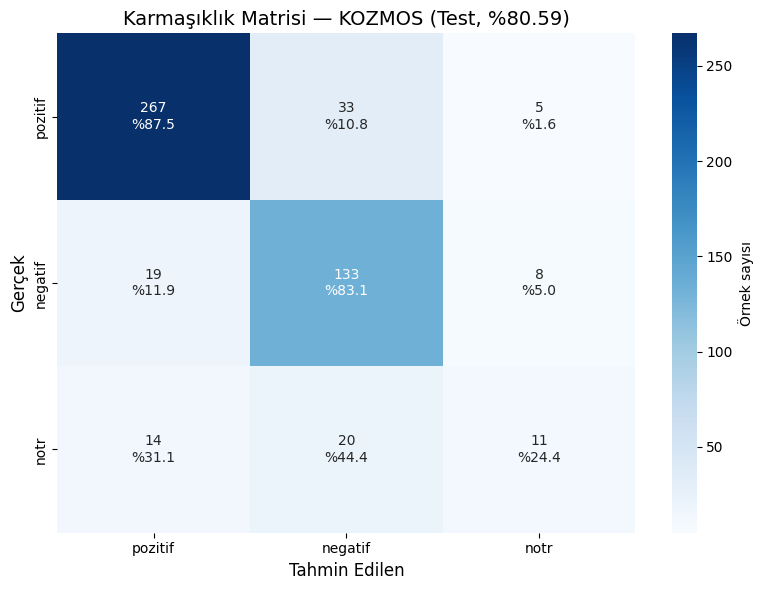

Kaydedildi: 01_karmasiklik_matrisi.png


In [18]:
from sklearn.metrics import confusion_matrix

labels_str = ["pozitif", "negatif", "notr"]
cm = confusion_matrix(y_true, y_pred, labels=labels_str)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100   # satır bazlı recall yüzdesi

annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n%{cm_pct[i, j]:.1f}"

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=labels_str, yticklabels=labels_str,
            cbar_kws={"label": "Örnek sayısı"})
plt.title(f"Karmaşıklık Matrisi — KOZMOS (Test, %{acc*100:.2f})", fontsize=14)
plt.xlabel("Tahmin Edilen", fontsize=12)
plt.ylabel("Gerçek", fontsize=12)
plt.tight_layout()
plt.savefig(VISUALS + "01_karmasiklik_matrisi.png", dpi=150)
plt.show()
print("Kaydedildi: 01_karmasiklik_matrisi.png")


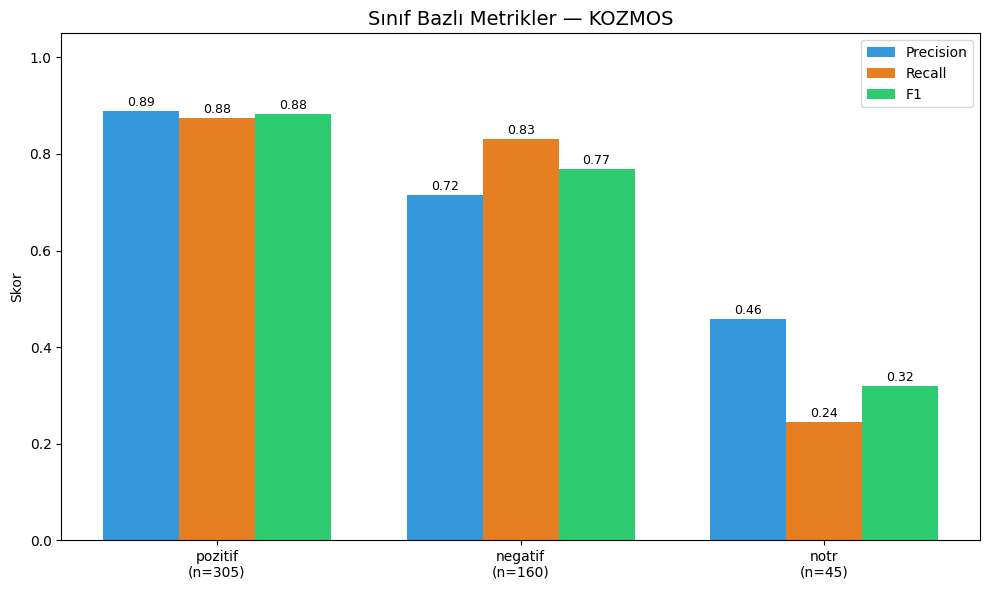

Kaydedildi: 02_sinif_metrikleri.png


In [19]:
from sklearn.metrics import precision_recall_fscore_support

p, r, f1, sup = precision_recall_fscore_support(
    y_true, y_pred, labels=labels_str, zero_division=0
)

x = np.arange(len(labels_str))
w = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - w, p,  w, label="Precision", color="#3498db")
plt.bar(x,     r,  w, label="Recall",    color="#e67e22")
plt.bar(x + w, f1, w, label="F1",        color="#2ecc71")

for i in range(len(labels_str)):
    for off, val in zip([-w, 0, w], [p[i], r[i], f1[i]]):
        plt.text(x[i] + off, val + 0.01, f"{val:.2f}", ha="center", fontsize=9)

plt.xticks(x, [f"{l}\n(n={s})" for l, s in zip(labels_str, sup)])
plt.ylim(0, 1.05)
plt.ylabel("Skor")
plt.title("Sınıf Bazlı Metrikler — KOZMOS", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS + "02_sinif_metrikleri.png", dpi=150)
plt.show()
print("Kaydedildi: 02_sinif_metrikleri.png")


/tmp/ipykernel_4387/3449929869.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=test_df, x="aspect", order=asp_order, palette="Set2")


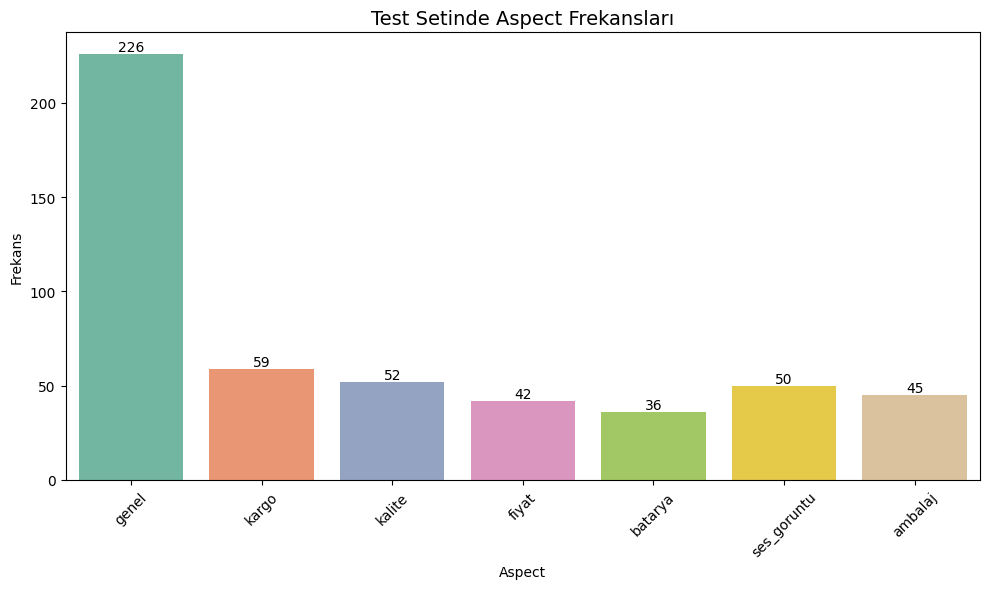

Kaydedildi: 03_aspect_frekanslari.png


In [20]:
asp_order = [a for a in ASPECTS if a in test_df["aspect"].values]

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=test_df, x="aspect", order=asp_order, palette="Set2")
for c in ax.containers:
    ax.bar_label(c, fontsize=10)
plt.title("Test Setinde Aspect Frekansları", fontsize=14)
plt.xlabel("Aspect"); plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(VISUALS + "03_aspect_frekanslari.png", dpi=150)
plt.show()
print("Kaydedildi: 03_aspect_frekanslari.png")


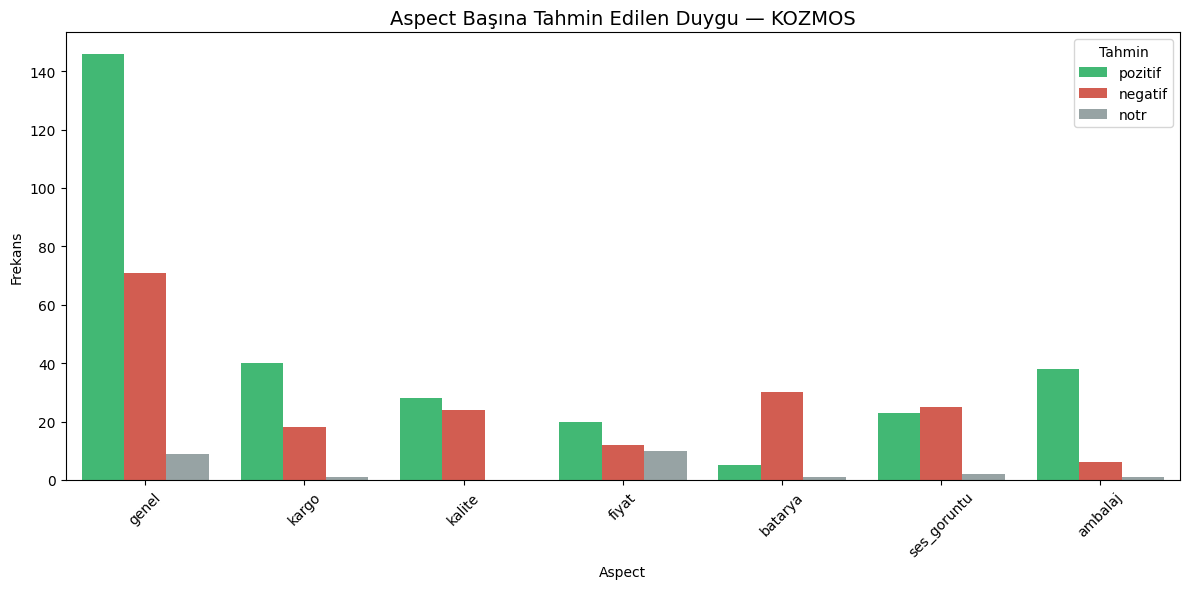

Kaydedildi: 04_aspect_sentiment_tahmin.png


In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=test_df, x="aspect", hue="tahmin",
              order=asp_order, hue_order=["pozitif", "negatif", "notr"],
              palette=RENKLER)
plt.title("Aspect Başına Tahmin Edilen Duygu — KOZMOS", fontsize=14)
plt.xlabel("Aspect"); plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.legend(title="Tahmin")
plt.tight_layout()
plt.savefig(VISUALS + "04_aspect_sentiment_tahmin.png", dpi=150)
plt.show()
print("Kaydedildi: 04_aspect_sentiment_tahmin.png")


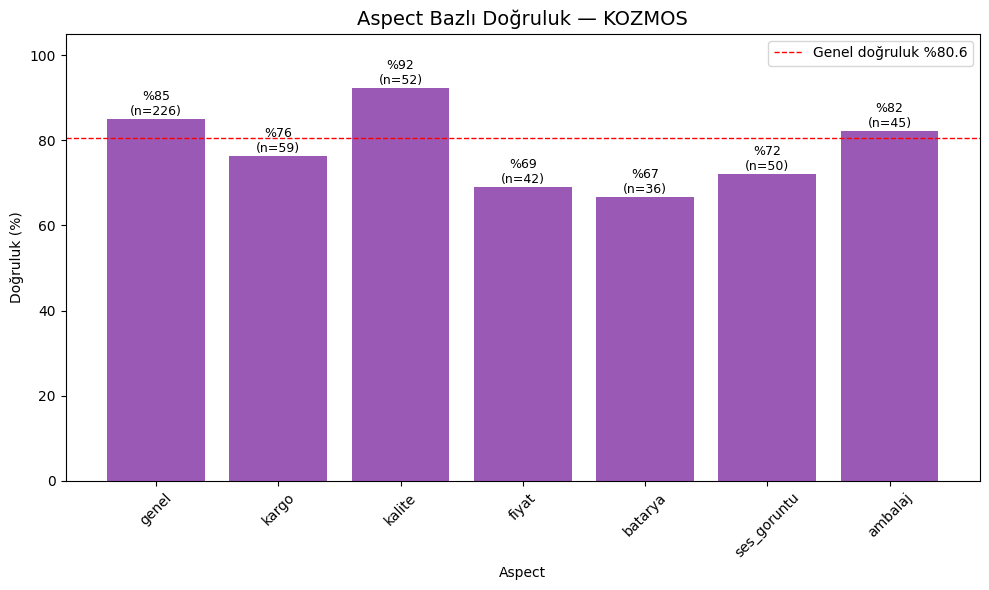

Kaydedildi: 05_aspect_dogruluk.png


In [22]:
test_df["dogru"] = (test_df["sentiment"] == test_df["tahmin"])
acc_by_aspect = test_df.groupby("aspect")["dogru"].mean().reindex(asp_order) * 100
n_by_aspect   = test_df.groupby("aspect").size().reindex(asp_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(acc_by_aspect.index, acc_by_aspect.values, color="#9b59b6")
for b, n in zip(bars, n_by_aspect.values):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             f"%{b.get_height():.0f}\n(n={n})", ha="center", fontsize=9)
plt.axhline(acc*100, color="red", ls="--", lw=1, label=f"Genel doğruluk %{acc*100:.1f}")
plt.ylim(0, 105)
plt.title("Aspect Bazlı Doğruluk — KOZMOS", fontsize=14)
plt.xlabel("Aspect"); plt.ylabel("Doğruluk (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS + "05_aspect_dogruluk.png", dpi=150)
plt.show()
print("Kaydedildi: 05_aspect_dogruluk.png")


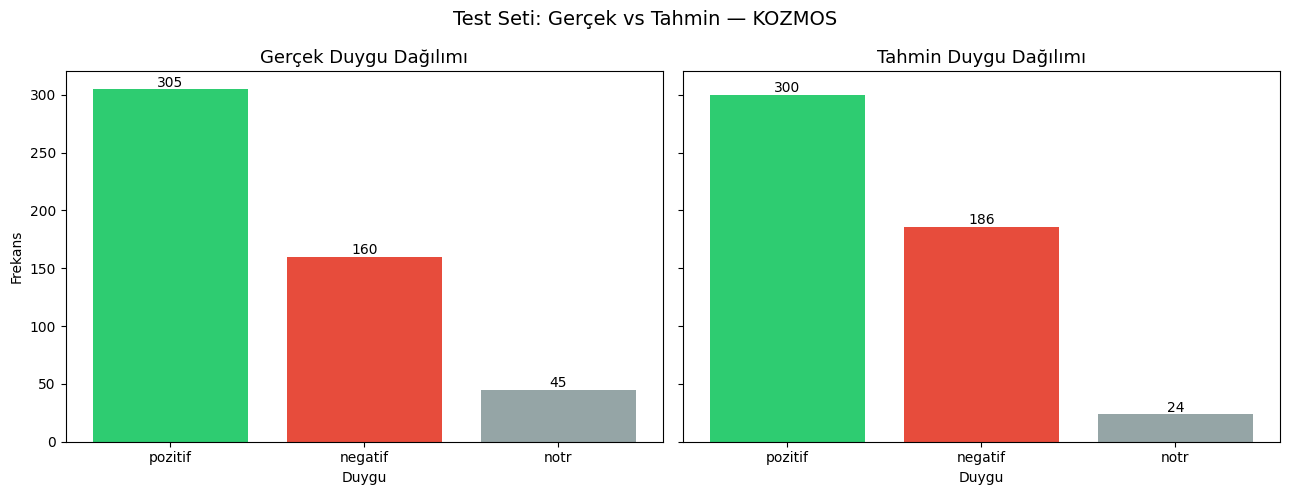

Kaydedildi: 06_gercek_vs_tahmin.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
order_s = ["pozitif", "negatif", "notr"]

for ax, col, baslik in zip(axes, ["sentiment", "tahmin"], ["Gerçek", "Tahmin"]):
    vc = test_df[col].value_counts().reindex(order_s)
    ax.bar(vc.index, vc.values, color=[RENKLER[s] for s in order_s])
    for i, v in enumerate(vc.values):
        ax.text(i, v + 2, str(v), ha="center", fontsize=10)
    ax.set_title(f"{baslik} Duygu Dağılımı", fontsize=13)
    ax.set_xlabel("Duygu")
axes[0].set_ylabel("Frekans")
plt.suptitle("Test Seti: Gerçek vs Tahmin — KOZMOS", fontsize=14)
plt.tight_layout()
plt.savefig(VISUALS + "06_gercek_vs_tahmin.png", dpi=150)
plt.show()
print("Kaydedildi: 06_gercek_vs_tahmin.png")


## 7. Aspect Duyarlılığı Analizi

Aynı yorumda farklı aspectler için farklı duygu etiketleri varsa,
modelin gerçekten aspect bilgisini kullanıp kullanmadığı daha net görülebilir.
Bu analiz, genel doğruluktan farklı olarak aspect koşullama başarısını ölçmeye çalışır.

Benzersiz yorum           : 333
Tek-aspect / Çoklu-aspect : 199 / 134
Aspect-çakışan yorum      : 31  (%9.3)

Genel doğruluk            : %80.6 (n=510)
Aspect-çakışan doğruluk   : %55.3 (n=76)

Çakışan 31 yorumdan farklı tahmin verilen: 3/31


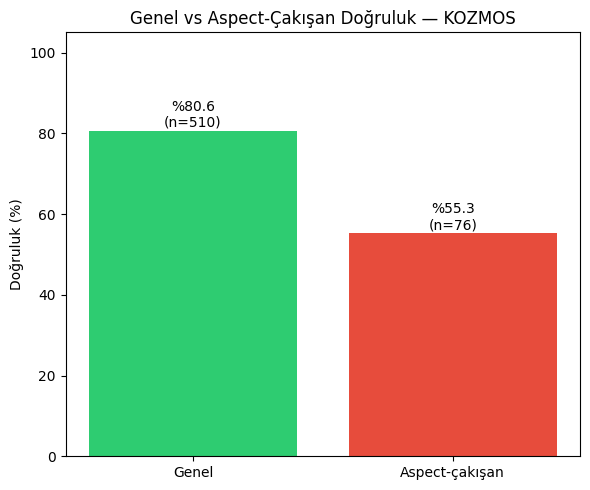

In [24]:
import collections

byyorum = collections.defaultdict(list)
for r in test_df.to_dict("records"):
    byyorum[str(r["yorum"]).strip()].append((r["aspect"], r["sentiment"], r["tahmin"]))

tek     = [y for y, v in byyorum.items() if len({a for a, _, _ in v}) == 1]
coklu   = [y for y, v in byyorum.items() if len({a for a, _, _ in v}) > 1]
cakisan = {y: v for y, v in byyorum.items() if len({s for _, s, _ in v}) > 1}

def dogruluk(rows):
    if not rows:
        return 0.0, 0
    c = sum(1 for r in rows if r["sentiment"] == r["tahmin"])
    return 100 * c / len(rows), len(rows)

cak_satir = [r for r in test_df.to_dict("records") if str(r["yorum"]).strip() in cakisan]
genel_acc, n_all = dogruluk(test_df.to_dict("records"))
cak_acc,   n_cak = dogruluk(cak_satir)
flip = sum(1 for v in cakisan.values() if len({t for _, _, t in v}) > 1)

print(f"Benzersiz yorum           : {len(byyorum)}")
print(f"Tek-aspect / Çoklu-aspect : {len(tek)} / {len(coklu)}")
print(f"Aspect-çakışan yorum      : {len(cakisan)}  (%{100*len(cakisan)/len(byyorum):.1f})")
print(f"\nGenel doğruluk            : %{genel_acc:.1f} (n={n_all})")
print(f"Aspect-çakışan doğruluk   : %{cak_acc:.1f} (n={n_cak})")
print(f"\nÇakışan {len(cakisan)} yorumdan farklı tahmin verilen: {flip}/{len(cakisan)}")

plt.figure(figsize=(6, 5))
bars = plt.bar(["Genel", "Aspect-çakışan"], [genel_acc, cak_acc],
               color=["#2ecc71", "#e74c3c"])
for b, a, n in zip(bars, [genel_acc, cak_acc], [n_all, n_cak]):
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
             f"%{a:.1f}\n(n={n})", ha="center")
plt.ylim(0, 105)
plt.ylabel("Doğruluk (%)")
plt.title("Genel vs Aspect-Çakışan Doğruluk — KOZMOS")
plt.tight_layout()
plt.savefig(VISUALS + "07_aspect_duyarlilik.png", dpi=150)
plt.show()

## 8. Veri Sızıntısı (Leakage) Kontrolü

Split satır bazlı yapıldığından aynı yorum hem train hem test'te yer alabilir.
Test yorumlarının ne kadarının train'de göründüğünü ve bunun doğruluğa etkisini ölçüyoruz.

In [25]:
ytr = set(train_df["yorum"].astype(str).str.strip())
ortak = set(test_df["yorum"].astype(str).str.strip()) & ytr
print(f"Train'de de görünen test yorumu: {len(ortak)} / {test_df['yorum'].nunique()} "
      f"(%{100*len(ortak)/test_df['yorum'].nunique():.1f})")

mask = test_df["yorum"].astype(str).str.strip().isin(ytr)
for ad, alt in [("Görülen yorum", test_df[mask]), ("Görülmeyen yorum", test_df[~mask])]:
    acc_alt = (alt["sentiment"] == alt["tahmin"]).mean() * 100
    print(f"  {ad:16s}: doğruluk %{acc_alt:.1f} (n={len(alt)})")
print("→ Aradaki fark, leakage'ın doğruluğu ne kadar şişirdiğini gösterir.")

Train'de de görünen test yorumu: 0 / 333 (%0.0)
  Görülen yorum   : doğruluk %nan (n=0)
  Görülmeyen yorum: doğruluk %80.6 (n=510)
→ Aradaki fark, leakage'ın doğruluğu ne kadar şişirdiğini gösterir.


## 9. Baseline Karşılaştırması

KOZMOS'un başarısını bağlama oturtmak için iki alt sınır: çoğunluk tahmini ve
klasik TF-IDF + Lojistik Regresyon.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

majority = test_df["sentiment"].value_counts(normalize=True).max() * 100
print(f"Majority baseline       : accuracy %{majority:.1f}")

Xtr = (train_df["yorum"].astype(str) + " " + train_df["aspect"].astype(str)).tolist()
Xte = (test_df["yorum"].astype(str) + " " + test_df["aspect"].astype(str)).tolist()
vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(vec.fit_transform(Xtr), train_df["label"])
base_pred = clf.predict(vec.transform(Xte))
print(f"TF-IDF + LogReg         : accuracy %{100*accuracy_score(test_df['label'], base_pred):.1f}, "
      f"macro F1 {f1_score(test_df['label'], base_pred, average='macro'):.3f}")
print(f"KOZMOS (bu çalışma)     : accuracy %{acc*100:.1f}, "
      f"macro F1 {f1_score(y_true, y_pred, average='macro'):.3f}")

Majority baseline       : accuracy %59.8
TF-IDF + LogReg         : accuracy %78.0, macro F1 0.643
KOZMOS (bu çalışma)     : accuracy %80.6, macro F1 0.657


## 10. Hatalı Tahmin Analizi

Modelin yanıldığı örnekleri, özellikle nötr sınıfını, niteliksel olarak inceliyoruz.

In [27]:
hatali = test_df[test_df["sentiment"] != test_df["tahmin"]]
print(f"Toplam hata: {len(hatali)} / {len(test_df)}")
print("\nNötr olması gerekirken kayan örnekler:")
for _, r in hatali[hatali["sentiment"] == "notr"].head(8).iterrows():
    print(f"  [{r['aspect']:11s}] gerçek=notr → tahmin={r['tahmin']:8s}: {str(r['yorum'])[:60]}")

Toplam hata: 99 / 510

Nötr olması gerekirken kayan örnekler:
  [kargo      ] gerçek=notr → tahmin=negatif : Ürün elime bugün 5 kasım 2024 tarihinde ulaştı, kutu üzerind
  [kargo      ] gerçek=notr → tahmin=negatif : acilen dönüş yaparmisiniz kargomuz geldi ama pin şifre var o
  [genel      ] gerçek=notr → tahmin=negatif : Biraz yavaş ama idare eder
  [genel      ] gerçek=notr → tahmin=negatif : Fiyat performans ürünü kasıyor donuyor idare eder
  [fiyat      ] gerçek=notr → tahmin=pozitif : Kardeşim için aldık paketlemesi güzeldi fiyat performans
  [genel      ] gerçek=notr → tahmin=pozitif : guzel ve kullanisli
  [ambalaj    ] gerçek=notr → tahmin=pozitif : iyiki almışım gerçekten çok iyi. paketleme normaldi ürün bay
  [batarya    ] gerçek=notr → tahmin=negatif : en alt seviye şarkı aralıksız 4 saat gidiyor şimdilik sadece


## 11. Aspect Demo — Dikkat ve Integrated Gradients

Modelin bir tahmini verirken hangi kelimelere dayandığını görselleştiriyoruz.
Integrated Gradients her kelimenin tahmini hangi yöne (pozitif/negatif) ittiğini
renkle gösterir; dikkat görünümü ise modelin yoğunlaştığı kelimeleri verir.

In [ ]:
!pip install captum -q
from transformers import AutoModelForSequenceClassification

TMP = "/content/kozmos_eager"
model.save_pretrained(TMP)
tokenizer.save_pretrained(TMP)
viz_model = AutoModelForSequenceClassification.from_pretrained(
    TMP, attn_implementation="eager"
).to(device).eval()
print("viz_model (eager) hazır.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 11.9 MB/s eta 0:00:00


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/73 [00:00<?, ?it/s]

viz_model (eager) hazır.


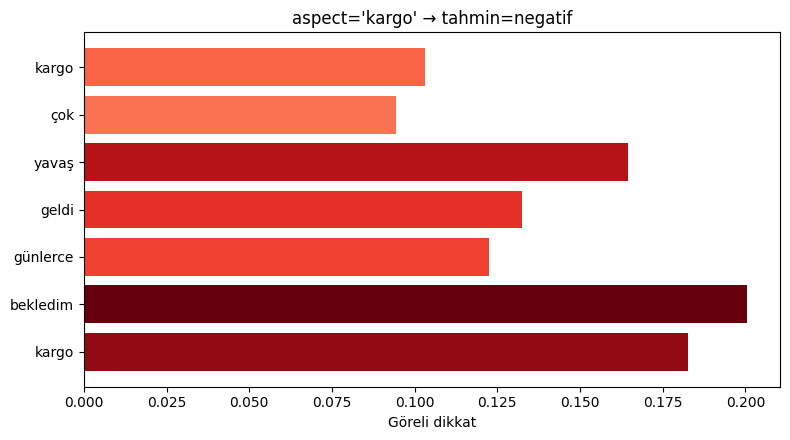

In [29]:
OZEL = {"[CLS]", "[SEP]", "[PAD]"}

def dikkat_gorseli(yorum, aspect, kayit=None):
    enc = tokenizer(f"{yorum} [SEP] {aspect}", return_tensors="pt",
                    truncation=True, max_length=128).to(device)
    with torch.no_grad():
        out = viz_model(**enc, output_attentions=True)
    att = out.attentions[-1][0].mean(0).cpu().numpy()   # son katman, head ortalaması
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    pred = INV_LABEL[out.logits.argmax(-1).item()]

    gelen = att.mean(axis=0)
    idx = [i for i, t in enumerate(tokens) if t not in OZEL]
    kelimeler = [tokens[i] for i in idx]
    skor = gelen[idx] / gelen[idx].sum()

    plt.figure(figsize=(8, 0.5 * len(kelimeler) + 1))
    plt.barh(range(len(kelimeler)), skor, color=plt.cm.Reds(skor / skor.max()))
    plt.yticks(range(len(kelimeler)), kelimeler)
    plt.gca().invert_yaxis()
    plt.xlabel("Göreli dikkat")
    plt.title(f"aspect='{aspect}' → tahmin={pred}")
    plt.tight_layout()
    if kayit:
        plt.savefig(kayit, dpi=150)
    plt.show()

dikkat_gorseli("kargo çok yavaş geldi günlerce bekledim", "kargo",
               kayit=VISUALS + "08_dikkat_ornek.png")

In [30]:
from captum.attr import LayerIntegratedGradients
from captum.attr import visualization as viz

ref_id = tokenizer.pad_token_id
cls_id, sep_id = tokenizer.cls_token_id, tokenizer.sep_token_id

def forward_func(input_ids, attention_mask):
    return viz_model(input_ids=input_ids, attention_mask=attention_mask).logits

lig = LayerIntegratedGradients(forward_func, viz_model.bert.embeddings)

def aciklama(yorum, aspect):
    enc = tokenizer(f"{yorum} [SEP] {aspect}", return_tensors="pt",
                    truncation=True, max_length=128).to(device)
    ids, mask = enc["input_ids"], enc["attention_mask"]
    logits = forward_func(ids, mask)
    pred_id = logits.argmax(-1).item()
    pred = INV_LABEL[pred_id]
    prob = torch.softmax(logits, -1)[0, pred_id].item()

    # Baseline: [CLS]/[SEP] korunur, içerik kelimeleri PAD'e indirilir
    ref = ids.clone()
    ozel = (ids == cls_id) | (ids == sep_id)
    ref[~ozel] = ref_id

    attr, delta = lig.attribute(
        inputs=ids, baselines=ref,
        additional_forward_args=(mask,),
        target=pred_id, n_steps=50, return_convergence_delta=True,
    )
    attr = attr.sum(dim=-1).squeeze(0)
    attr = (attr / torch.norm(attr)).cpu().detach().numpy()
    tokens = tokenizer.convert_ids_to_tokens(ids[0])

    rec = viz.VisualizationDataRecord(
        word_attributions=attr, pred_prob=prob, pred_class=pred,
        true_class="-", attr_class=pred, attr_score=attr.sum(),
        raw_input_ids=tokens, convergence_score=delta,
    )
    return viz.visualize_text([rec])

# Tek-kutuplu (başarı) ve aspect-çakışan (sınır) örnekler:
aciklama("ürün harika kaliteli çok memnunum", "kalite")
aciklama("telefon çok güzel ama kargo çok yavaştı", "genel")
aciklama("telefon çok güzel ama kargo çok yavaştı", "kargo")

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
-,pozitif (0.98),pozitif,2.25,[CLS] ürün harika kaliteli çok memnunum [SEP] kalite [SEP]


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
-,negatif (0.92),negatif,1.06,[CLS] telefon çok güzel ama kargo çok yavaş ##tı [SEP] genel [SEP]


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
-,negatif (0.89),negatif,1.00,[CLS] telefon çok güzel ama kargo çok yavaş ##tı [SEP] kargo [SEP]


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
-,negatif (0.89),negatif,1.00,[CLS] telefon çok güzel ama kargo çok yavaş ##tı [SEP] kargo [SEP]


In [31]:
import shutil
from google.colab import files
shutil.make_archive("/content/visuals_kozmos", "zip", VISUALS)
files.download("/content/visuals_kozmos.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>